# <span style="color:darkblue"> Assignment 4: Textual Analysis of Bills and Actions from 116th Congress of the United States  </span>

<font size = 4>
By: Tanya Jagdish

<b> Import libraries

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud, STOPWORDS

<b> Load dataset

In [104]:
bills_actions = pd.read_csv("data_raw/bills_actions.csv")

##  <span style="color:darkblue"> <b> 1. Understanding the data + basic descriptive statistics

<b> <i> 1.1 How many distinct "bill" identifiers are there? </b>

In [105]:
bills_actions.dtypes
n_bills = bills_actions["bill_number"].nunique()
n_rows = len(bills_actions)
print(f"Distinct # of bills: {n_bills:,} | Total rows in dataset: {n_rows:,}")

Distinct # of bills: 1,331 | Total rows in dataset: 3,303


<b> <i> 1.2 What proportion of the rows belong to different categories? </b>

In [106]:
category_proportions = (bills_actions["category"]
                        .value_counts(normalize = True)
                        .mul(100).round(2)
                        .rename("% of rows"))

category_proportions

category
amendment                       46.29
house bill                      27.31
senate bill                     15.56
house resolution                 7.08
senate resolution                1.82
house joint resolution           0.67
house concurrent resolution      0.61
senate concurrent resolution     0.42
senate joint resolution          0.24
Name: % of rows, dtype: float64

<b> <i> 1.3 Within each category, what's the proportion of rows that belongs to different “main_action”? </b>

In [107]:
#count number of main_action rows within each category
main_action_by_cat = (bills_actions
                      .groupby("category")["main_action"]
                      .value_counts()
                      .rename("Count of rows")
                      .reset_index()
)

#calculate proportion
main_action_by_cat["% of main action within each category"] = (main_action_by_cat
                             .groupby("category")["Count of rows"]
                             .transform(lambda x: x / x.sum()*100)
                             .round(2))

#pretty formatting
main_action_by_cat.style.hide(axis="index").format({"Count of rows": "{:,.0f}", "% of main action within each category": "{:.2f}%"})

category,main_action,Count of rows,% of main action within each category
amendment,house amendment offered,828,54.15%
amendment,other house amendment actions,397,25.96%
amendment,senate amendment proposed (on the floor),286,18.71%
amendment,other senate amendment actions,18,1.18%
house bill,house floor actions,702,77.83%
house bill,house committee/subcommittee actions,132,14.63%
house bill,senate committee/subcommittee actions,54,5.99%
house bill,resolving differences -- house actions,6,0.67%
house bill,senate floor actions,5,0.55%
house bill,resolving differences -- senate actions,3,0.33%


##  <span style="color:darkblue"> <b>2. House floor actions on Senate bills

<b>Overview: </b>

To understand cross-chamber dynamic, we are looking at House floor actions on Senate bills. 

A few conceptual notes on the data:

* A senate bill originates in the Senate

* But once a bill passes the Senate, it moves to the House, where it can be debated, ammended, or voted on

* All these steps (except ammendment) are recorded as 'House floor actions' in the column 'main_action'

Given this, I first calculate the number of house floor actions on senate bills

### <b> 2.1 Number of house floor actions on senate bills

In [108]:
# filter for Senate bills and House floor actions
house_floor_in_senate = bills_actions.query(
    'category == "senate bill" and main_action == "house floor actions"'
)

# number of such rows
total_actions = len(house_floor_in_senate)
print(f"Number of House floor actions on Senate bills: {total_actions:,}")


Number of House floor actions on Senate bills: 116


### <b>2.2 Proportion of these actions that were suspended and suspended as ammended

In [109]:
# prop of bills suspended
suspended = house_floor_in_senate["action"].str.contains("suspend", case = False, na = False)
prop_suspended = suspended.mean()*100

# prop of bills suspended as ammended
suspended_amended = house_floor_in_senate["action"].str.contains("suspend", case=False, na=False) & \
                    house_floor_in_senate["action"].str.contains("amend", case=False, na=False)
prop_suspended_amended = suspended_amended.mean() * 100

#display results
print(f"Total House floor actions on Senate bills: {total_actions:,}")
print(f"Proportion suspended: {prop_suspended:.2f}%")
print(f"Proportion suspended as amended: {prop_suspended_amended:.2f}%")

Total House floor actions on Senate bills: 116
Proportion suspended: 68.97%
Proportion suspended as amended: 15.52%


### <b>2.3 Names of legislators mentioned in House floor actions

<b> Overview </b>:

Conceptually, in this section, we are looking at which legislators are mentioned in the House floor action text (in column 'action' within the dataset)

For instance, if the action column says "On motion of Mr. Smith, the rules were suspended and the bill passed," we want to try to pull out "Smith" from the text

To do this, we will:

1. Use regular expression patterns to pull out all names that follow "Mr.", "Mrs.", "Ms."

2. Expand those into a dataset of person-bill pairs

3. Count how many distinct bills each person is mentioned in (e.g., if "Mr. Smith" appears in 3 different bills, count = 3)

4. Visualize or describe the distribution (e.g., many people mentioned once, few mentioned multiple times, etc.)

In [110]:
#string pattern
pattern = r"(?i)\b(?:Mrs|Ms|Mr)\.?\s*(\S+)"

#sanity check - making sure code works
tests = [
    "Mrs. Smith moved to suspend the rules.",
    "Mr Jones spoke.",
    "ms O'Neill objected.",
    "MRS  De-Lauro offered an amendment."
]

#pd.Series(tests).str.findall(pattern)


<i> <b> Note on the regular expression pattern chosen above </i> </b>

* \b - for word boundary

* (?i) - case insensitive (e.g., matches Mr. or mr.)

* (?:mrs|ms|mr) - a non-capturing group matching one of the titles. I intentionally choose to order it as 'mrs|ms|mr' to search for 'mrs' first and then 'mr'

* \ . ? - an optional dot after the title (e.g., matches Mr. or mr)

* \s* - zero or more spaces between title and the name

* (\S+) - capturing group of one or more non-space characters

In [149]:
#search for names
names = house_floor_in_senate["action"].str.findall(pattern)

#add names column to dataset
house_floor_in_senate["Name"] = names

#convert list of names to string of names
house_floor_in_senate["Name"] = house_floor_in_senate["Name"].str[0]

#remove rows with no person and keep only person, bill_number column
bill_person_pair = house_floor_in_senate.dropna(subset = ["Name"])[["bill_number", "Name"]]

#house_floor_in_senate.head()
#bill_person_pair.head()

#count bill per person
bills_per_person = (
    bill_person_pair
    .groupby("Name")["bill_number"] #groups results by person
    .nunique() #counts num unique bills
    .reset_index(name = "Number of bills") #renames col
    .sort_values("Number of bills", ascending=False)
)

#bills_per_person.style

C:\Users\tanya\AppData\Local\Temp\ipykernel_33864\328658170.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  house_floor_in_senate["Name"] = names
C:\Users\tanya\AppData\Local\Temp\ipykernel_33864\328658170.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  house_floor_in_senate["Name"] = house_floor_in_senate["Name"].str[0]


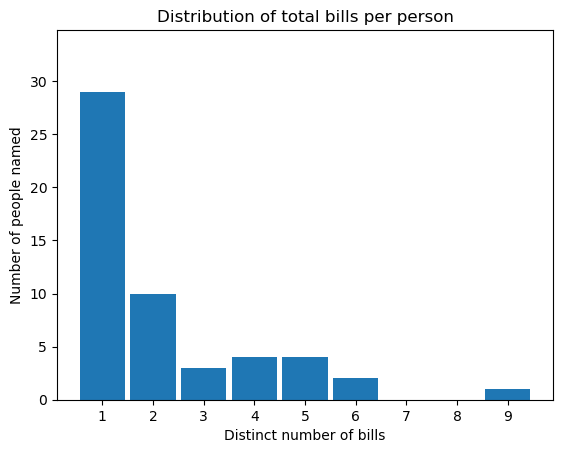

In [156]:
max = bills_per_person["Number of bills"].max()


plt.hist(bills_per_person["Number of bills"], bins=range(1, max+2), align="left", rwidth=0.9)
plt.xticks(range(1, max+1))
plt.xlabel("Distinct number of bills")
plt.ylabel("Number of people named")
plt.title("Distribution of total bills per person")
plt.margins(y=0.2)
plt.show()

<b> <i> Analysis notes: </b> </i>

* Most legislators are only mentioned proposing one bill. Meaning their participation in House floor actions on Senate bills is limited to a single instance.

* Around 10 legislators are mentioned in two bills

* Very few legislators (fewer than five) appear in three or more bills. And only one person is referenced in as many as nine bills

* This creates a right-skewed distribution, where the vast majority of names occur once and a handful of highly active members appear repeatedly

* In other words, bill sponsorship and floor mentions are concentrated among a small, active subset of legislators, while most representatives appear only occasionally in the official record


##  <span style="color:darkblue"> <b>3. Bills marked as "Senate amendment proposed (on the floor)"

<b> Overview: </b>

* In this section, we focus on a subset of bills whose actions are marked as "senate amendment proposed (on the floor)" within 'main_action' column

* In the previous section, actions only mentioned one legislator names

* Whereas actions for bills marked as "senate amendment proposed (on the floor)" can have more than one senator name mentioned 

Given this contextual information, in section 3, we will focus on understanding the senators mentioned in the actions of these bills

### <b> 3.1 Senators mentioned per bill

Goal: create a dataset counting how many senators are mentioned per bill

In [175]:
#filter rows
amendments = bills_actions.query(
    'main_action == "senate amendment proposed (on the floor)"')

#understand dataset
print(amendments.shape)

#create regular expression
expression = r"(?i)\b(?:sen\.?|senator)\s+[A-Z][a-zA-Z'\-]+"

(286, 7)


<i> <b> Note on the regular expression chosen above </i> </b>

* \b - for word boundary, avoids partial matches

* (?i) - case insensitive (e.g., matches 'sen' and "Sen")

* (?:sen\.?|senator) – non-capturing group for the title

    * sen\.? matches Sen or Sen.
    
    * senator matches the full word Senator

* \s+ - zero or more spaces between title and the name

* ([A-Z][A-Za-z'-]+) - capturing group for the surname: a capital letter followed by one or more letters, apostrophes, or hyphens (e.g., Brown, O'Neill, De-Lauro)

C:\Users\tanya\AppData\Local\Temp\ipykernel_33864\864905152.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amendments["senators"] = amendments["action"].str.findall(expression)
C:\Users\tanya\AppData\Local\Temp\ipykernel_33864\864905152.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amendments["num_senators"] = amendments["senators"].apply(len)
C:\Users\tanya\AppData\Local\Temp\ipykernel_33864\864905152.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

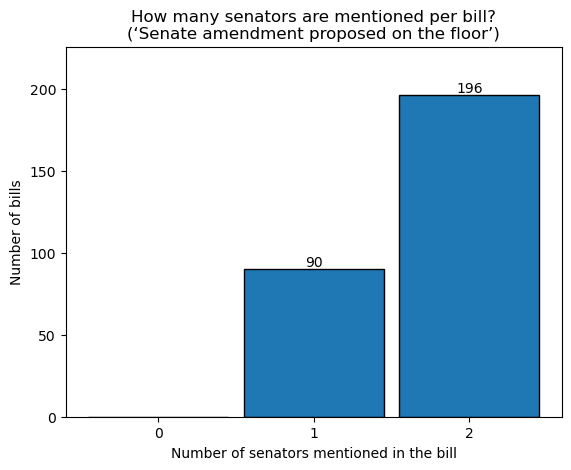

In [174]:
#extract senator names using regular expressions
amendments["senators"] = amendments["action"].str.findall(expression)

#checking if code works
# amendments[["bill_number", "main_action", "senators"]].head()

# Count number of senators mentioned in each action
amendments["num_senators"] = amendments["senators"].apply(len)

#extract first and second senator names
amendments["Senator_1"] = amendments["senators"].str[0]
amendments["Senator_2"] = amendments["senators"].str[1]

#create final dataframe
senator_mentions = amendments[["bill_number", "num_senators", "Senator_1", "Senator_2"]].copy()
#senator_mentions.head(10)

#plot results

# Build integer bins: 0..max
mx = int(amendments["num_senators"].max())
bins = np.arange(0, mx + 2)  # e.g., 0-1, 1-2, ... so bars center on 0,1,2,...

fig, ax = plt.subplots()
ax.hist(amendments["num_senators"], bins=bins, align="left", rwidth=0.9, edgecolor="black")

# Titles and labels
ax.set_title("How many senators are mentioned per bill?\n(‘Senate amendment proposed on the floor’)")
ax.set_xlabel("Number of senators mentioned in the bill")
ax.set_ylabel("Number of bills")

# Integer x-ticks at 0..mx
ax.set_xticks(range(0, mx + 1))

# Optional: annotate bar tops with counts
counts, _ = np.histogram(amendments["num_senators"], bins=bins)
for x, y in zip(range(0, mx + 1), counts):
    if y > 0:
        ax.text(x, y, str(y), ha="center", va="bottom")

ax.margins(y=0.15)
plt.show()


<b> <i> Insights </b></i>:

* About 196 of 286 bills have atleast two senators that are proposing amendments to the bill

* Only 90 bills have single senator author proposing amendments

### <b> 3.2 How many different people appear as Senator 2 for each Senator 1?

Goal: We want to know for each Senator_1, how many different people appear as Senator_2 (their coauthors across bills)

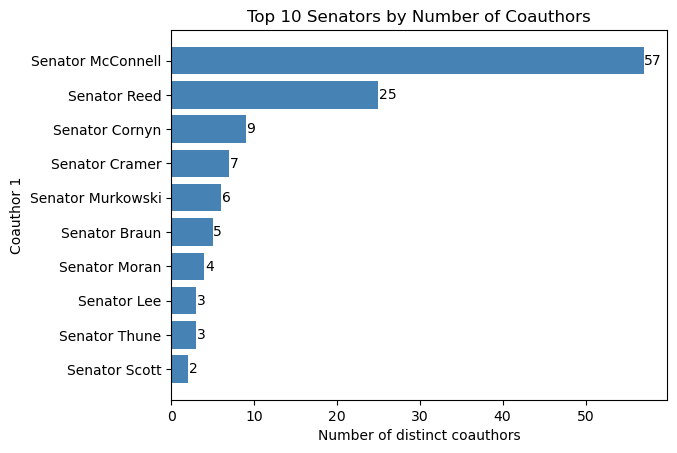

In [183]:
# copy dataset
senator_pairs = senator_mentions.copy()

# Drop rows where there is no Senator_2 (i.e., single-senator bills)
senator_pairs = senator_pairs.dropna(subset=["Senator_1", "Senator_2"])

# Group by Senator_1, and count unique Senator_2 names they’ve coauthored with
coauthor_counts = (
    senator_pairs
      .groupby("Senator_1")["Senator_2"]
      .nunique()                         # count distinct coauthors
      .reset_index(name="num_coauthors")
      .sort_values("num_coauthors", ascending=False)
)

#coauthor_counts.head(10)

#plot results

top = coauthor_counts.head(10)

fig, ax = plt.subplots()
ax.barh(top["Senator_1"], top["num_coauthors"], color="steelblue")
ax.invert_yaxis()
ax.set_title("Top 10 Senators by Number of Coauthors")
ax.set_xlabel("Number of distinct coauthors")
ax.set_ylabel("Coauthor 1")
for i, (name, val) in enumerate(zip(top["Senator_1"], top["num_coauthors"])):
    ax.text(val + 0.1, i, str(val), va="center")
plt.show()



#### 3.2.1 Experimenting with different visualizations 

<b> Heat map - who collaborates together the most?

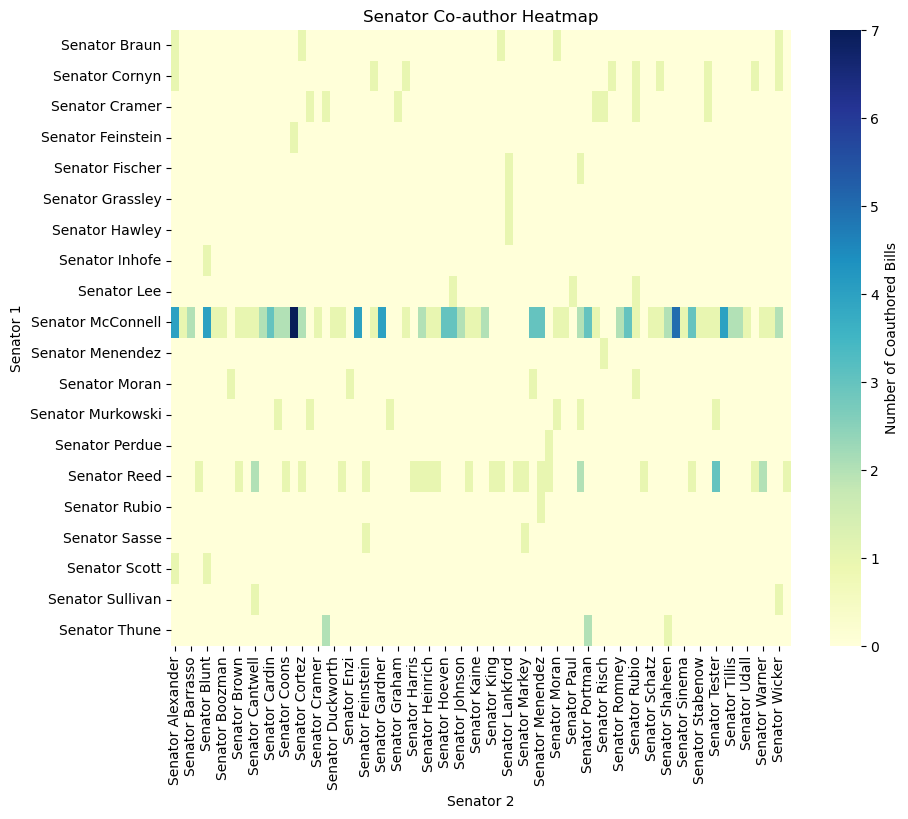

In [182]:
import seaborn as sns

matrix = (
    senator_mentions
      .dropna(subset=["Senator_1", "Senator_2"])
      .pivot_table(index="Senator_1", columns="Senator_2", aggfunc="size", fill_value=0)
)

plt.figure(figsize=(10,8))
sns.heatmap(matrix, cmap="YlGnBu", cbar_kws={'label': 'Number of Coauthored Bills'})
plt.title("Senator Co-author Heatmap")
plt.xlabel("Senator 2")
plt.ylabel("Senator 1")
plt.show()


<i><b> Analysis notes: </i> </b>

* Senator McConnell stands out dramatically, appearing with 57 distinct coauthors. This is more than twice as many as the next most collaborative senator.

* This suggests he plays a central, coordinating role in legislative activity, likely managing or introducing a large volume of amendments involving multiple senators.

* Grounding this in present-day politics, our results make sense because Senator Mitch McConnell served as the Senate party leader from 2015-2021.

* I thought it was particularly interesting that Senator McConnell collaborated across a breadth of different senators as seen on the heat map. 

* Senator Reed follows with 25 coauthors, showing a strong but more limited collaborative network.

* The remaining senators (Cornyn, Cramer, Murkowski, Braun, Moran, Lee, Thune, and Scott) have between 2 and 9 coauthors each, indicating far smaller collaboration circles. But the rest of senators have one or less coauthored bills